# A2 Kaggle Competition: Boy or Girl 2026 new
- Group : Team
- Group member
- 111403016 邱玟碩
- 111403038 戴宇偵
- 114423029 王品淳
- 114423042 劉和媛

In [1]:
# import packages
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier

## Phase 1: Data Preparation and Leakage Prevention
Load the dataset and perform a train–test split in advance to create a validation set, ensuring that no data leakage occurs during subsequent processing.

In [2]:
train_path = 'data/boy or girl 2025 train_missingValue.csv'
test_path = 'data/boy or girl 2025 test no ans_missingValue.csv'

df_train_full = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

X_full = df_train_full.drop(columns=['gender'])
y_full = df_train_full['gender']

X_train, X_valid, y_train, y_valid = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)
print('Train shape:', X_train.shape)
print('Valid shape:', X_valid.shape)
print('Test shape:', df_test.shape)

Train shape: (338, 10)
Valid shape: (85, 10)
Test shape: (426, 11)


## Phase 2: Feature Engineering
we perform data preprocessing, anomaly handling, and feature extraction on the dataset, including numerical, categorical, and textual features.

In [3]:
def is_repeated_or_symbol(s):
    if pd.isna(s) or s == '' or s == 'nan': return False
    if re.fullmatch(r'[^A-Za-z0-9\u4e00-\u9fff]+', s): return True
    if re.fullmatch(r'(.)\1{3,}', s): return True
    return False

def build_features(df):
    df = df.copy()
    
    # Phase 0: yt & phone_os
    if 'yt' in df.columns:
        orig_yt = df['yt']
        df['yt'] = pd.to_numeric(df['yt'], errors='coerce')
        df['is_yt_invalid'] = np.where(orig_yt.notna() & df['yt'].isna(), 1, 0)
    
    if 'phone_os' in df.columns:
        df['phone_os_clean'] = df['phone_os'].astype(str).str.strip().str.lower().replace({'iphone': 'apple'})
        valid_os = {'android', 'apple', 'windows'}
        df['is_phone_os_invalid'] = np.where(df['phone_os_clean'].isin(valid_os), 0, 1)
        df.loc[df['is_phone_os_invalid'] == 1, 'phone_os_clean'] = 'Unknown'
        df.drop(columns=['phone_os'], inplace=True, errors='ignore')

    # Phase 1: anomaly handling
    if 'weight' in df.columns:
        df['is_weight_missing'] = df['weight'].isna().astype(int)
        df['is_weight_outlier'] = np.where(df['weight'].notna() & ((df['weight'] < 30) | (df['weight'] > 1000)), 1, 0)
        df['weight'] = df['weight'].clip(lower=40, upper=120)

    if 'height' in df.columns:
        df['is_height_missing'] = df['height'].isna().astype(int)
        df['is_height_outlier'] = np.where(df['height'].notna() & ((df['height'] < 130) | (df['height'] > 220)), 1, 0)
        df['height'] = df['height'].clip(lower=140, upper=200)

    if 'iq' in df.columns:
        df['is_iq_outlier'] = np.where(df['iq'].notna() & ((df['iq'] < 100) | (df['iq'] > 140)), 1, 0)
        df['iq'] = df['iq'].clip(lower=100, upper=140)

    if 'fb_friends' in df.columns:
        df['is_fb_friends_outlier'] = np.where(df['fb_friends'].notna() & ((df['fb_friends'] < 0) | (df['fb_friends'] > 2000)), 1, 0)
        df['fb_friends'] = df['fb_friends'].clip(lower=0, upper=2000)

    if 'yt' in df.columns:
        df['is_yt_outlier'] = np.where(df['yt'].notna() & ((df['yt'] < 0) | (df['yt'] > 24)), 1, df.get('is_yt_invalid', 0))
        df['yt'] = df['yt'].clip(lower=0, upper=24)

    if 'star_sign' in df.columns:
        # print(df['star_sign'])
        star_map = {
            '牡羊座': 'aries', '金牛座': 'taurus', '雙子座': 'gemini', '巨蟹座': 'cancer',
            '獅子座': 'leo', '處女座': 'virgo', '天秤座': 'libra', '天蠍座': 'scorpio',
            '射手座': 'sagittarius', '摩羯座': 'capricorn', '水瓶座': 'aquarius', '雙魚座': 'pisces'
        }

        if 'star_sign' in df.columns:
            # data cleaning for star_sign
            df['star_sign_clean'] = df['star_sign'].astype(str).str.strip()
            # print(df['star_sign'])


            df['is_star_sign_invalid'] = np.where(
                df['star_sign_clean'].isin(star_map.keys()), 
                0, 1
            )
            
            
            # translate: map english names, those not in the map will be filled with 'Unknown'
            df['star_sign_clean'] = df['star_sign_clean'].map(star_map).fillna('Unknown')
            
            df.drop(columns=['star_sign'], inplace=True, errors='ignore')


    # Phase 2: self_intro text features extraction
    if 'self_intro' in df.columns:
        df['is_intro_missing'] = df['self_intro'].isna().astype(int)
        df['intro_char_length'] = df['self_intro'].fillna('').astype(str).str.len()
        df['intro_word_count'] = df['self_intro'].fillna('').astype(str).str.split().apply(len)
        df['intro_is_all_lower'] = df['self_intro'].fillna('').astype(str).apply(lambda s: s.islower() if s else False).astype(int)
        df['intro_is_all_upper'] = df['self_intro'].fillna('').astype(str).apply(lambda s: s.isupper() if s else False).astype(int)

        df['is_intro_anomalous'] = 0
        df.loc[df['intro_char_length'] == 0, 'is_intro_anomalous'] = 1
        df.loc[df['intro_char_length'] > 500, 'is_intro_anomalous'] = 1
        df.loc[df['self_intro'].fillna('').astype(str).apply(is_repeated_or_symbol), 'is_intro_anomalous'] = 1
        
        # set anomalous intros to NaN so they can be imputed or encoded later, instead of dropping them here
        df.loc[df['is_intro_anomalous'] == 1, 'self_intro'] = np.nan
        
    return df

X_train_clean = build_features(X_train)
X_valid_clean = build_features(X_valid)
X_test_clean = build_features(df_test)

print("feature engineering done")

# test = build_features(X_train[X_train['id'] == 163])

feature engineering done


## Phase 3: Preprocessing Overview 
Includes imputation for numerical and categorical features, also categorical features encoding (one-hot and semantic)
1. `SelfIntroEncoder`: compute text prototypes/PCA only in `fit(train)`; `transform` only applies the learned mapping.
2. `TabularPreprocessor`: perform imputation and define one-hot columns only in `fit(train)`; `transform` aligns columns.
3. `FullPreprocessor`: chain the two stages above so each CV fold can be fitted independently, preventing leakage.
4. Usage:
   - Without CV: use `run_preprocess_no_cv_v2(...)`
   - With CV: use `preprocess_one_fold_v2(...)` in each fold

In [4]:
import copy
from dataclasses import dataclass

from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# Default setting for class-based pipeline (kept for backward compatibility)
if 'SELF_INFO_BERT_PCA_COMPONENTS' not in globals():
    SELF_INFO_BERT_PCA_COMPONENTS = -1


@dataclass
class SelfIntroEncoderConfig:
    model_name: str = 'paraphrase-multilingual-MiniLM-L12-v2'
    pca_components: int = -1  # -1: prototype only, 0: full emb, > 0: PCA dims
    use_gender_prototype: bool = True


class SelfIntroEncoder:
    # Class-level caches shared by all encoder instances
    _MODEL_CACHE = {}
    _TEXT_EMBED_CACHE = {}

    def __init__(self, config: SelfIntroEncoderConfig):
        self.config = config
        self.model = None  # kept for compatibility/debugging
        self.pca = None
        self.male_centroid = None
        self.female_centroid = None
        self.emb_cols = None
        self.is_fitted = False

    @classmethod
    def _get_or_create_model(cls, model_name):
        if model_name not in cls._MODEL_CACHE:
            cls._MODEL_CACHE[model_name] = SentenceTransformer(model_name)
        return cls._MODEL_CACHE[model_name]

    @classmethod
    def _get_or_create_embed_cache(cls, model_name):
        if model_name not in cls._TEXT_EMBED_CACHE:
            cls._TEXT_EMBED_CACHE[model_name] = {}
        return cls._TEXT_EMBED_CACHE[model_name]

    @staticmethod
    def _has_intro_mask(df):
        text_non_empty = df['self_intro'].fillna('').astype(str).str.strip().ne('')
        if 'is_intro_missing' in df.columns:
            return df['is_intro_missing'].fillna(0).astype(int).eq(0) & text_non_empty
        return text_non_empty

    @staticmethod
    def _resolve_gender_labels(y):
        y_s = pd.Series(y)
        uniq = sorted(y_s.dropna().unique().tolist())
        if set([1, 2]).issubset(set(uniq)):
            return 1, 2
        if len(uniq) == 2:
            # For shifted labels (e.g., 0/1), treat the smaller label as class-1 counterpart.
            return uniq[0], uniq[1]
        raise ValueError(f'Expected binary labels, got: {uniq}')

    def _encode_text(self, df):
        text_list = df['self_intro'].fillna('').astype(str).tolist()
        if len(text_list) == 0:
            return np.zeros((0, 0), dtype=np.float32)

        model = SelfIntroEncoder._get_or_create_model(self.config.model_name)
        self.model = model
        embed_cache = SelfIntroEncoder._get_or_create_embed_cache(self.config.model_name)

        # Encode only unseen text and store embeddings in shared cache.
        missing_texts = [t for t in dict.fromkeys(text_list) if t not in embed_cache]
        if len(missing_texts) > 0:
            missing_emb = model.encode(missing_texts, convert_to_numpy=True, normalize_embeddings=True)
            for t, e in zip(missing_texts, missing_emb):
                embed_cache[t] = e

        emb = np.vstack([embed_cache[t] for t in text_list])
        return emb

    def fit(self, X_df, y=None):
        emb = self._encode_text(X_df)

        if self.config.use_gender_prototype:
            if y is None:
                raise ValueError('y is required when use_gender_prototype=True')

            male_label, female_label = SelfIntroEncoder._resolve_gender_labels(y)
            y_s = pd.Series(y, index=X_df.index)
            has_intro = SelfIntroEncoder._has_intro_mask(X_df)

            male_mask = (y_s == male_label) & has_intro
            female_mask = (y_s == female_label) & has_intro
            if male_mask.sum() == 0:
                male_mask = (y_s == male_label)
            if female_mask.sum() == 0:
                female_mask = (y_s == female_label)

            self.male_centroid = emb[male_mask.to_numpy()].mean(axis=0)
            self.female_centroid = emb[female_mask.to_numpy()].mean(axis=0)

        if self.config.pca_components > 0:
            self.pca = PCA(n_components=self.config.pca_components, random_state=42)
            emb_reduced = self.pca.fit_transform(emb)
            self.emb_cols = [f'bert_feat_{i}' for i in range(emb_reduced.shape[1])]
        elif self.config.pca_components == 0:
            self.emb_cols = [f'bert_feat_{i}' for i in range(emb.shape[1])]

        self.is_fitted = True
        return self

    def transform(self, X_df):
        if not self.is_fitted:
            raise RuntimeError('SelfIntroEncoder must be fitted before transform().')

        emb = self._encode_text(X_df)
        features = []

        if self.config.use_gender_prototype:
            sim_m = emb @ self.male_centroid
            sim_f = emb @ self.female_centroid
            has_intro = SelfIntroEncoder._has_intro_mask(X_df).to_numpy()
            sim_m = np.where(has_intro, sim_m, 0.0)
            sim_f = np.where(has_intro, sim_f, 0.0)
            proto_df = pd.DataFrame({
                'self_intro_sim_to_male': sim_m,
                'self_intro_sim_to_female': sim_f,
                # 'self_intro_male_minus_female': sim_m - sim_f
            }, index=X_df.index)
            features.append(proto_df)

        if self.config.pca_components == 0:
            emb_df = pd.DataFrame(emb, columns=self.emb_cols, index=X_df.index)
            features.append(emb_df)
        elif self.config.pca_components > 0:
            emb_reduced = self.pca.transform(emb)
            emb_df = pd.DataFrame(emb_reduced, columns=self.emb_cols, index=X_df.index)
            features.append(emb_df)

        return pd.concat(features, axis=1) if features else pd.DataFrame(index=X_df.index)


class FeaturePipeline:
    def __init__(self, self_intro_encoder: SelfIntroEncoder = None):
        self.self_intro_encoder = self_intro_encoder
        self.is_fitted = False

    def clone(self):
        return copy.deepcopy(self)

    def _base_transform(self, X_df):
        return build_features(X_df)

    def fit(self, X_df, y=None):
        X_base = self._base_transform(X_df)
        if self.self_intro_encoder is not None:
            self.self_intro_encoder.fit(X_base, y)
        self.is_fitted = True
        return self

    def transform(self, X_df):
        if not self.is_fitted:
            raise RuntimeError('FeaturePipeline must be fitted before transform().')

        X_base = self._base_transform(X_df)
        if self.self_intro_encoder is not None:
            intro_feat = self.self_intro_encoder.transform(X_base)
            X_base = X_base.drop(columns=['self_intro'], errors='ignore')
            X_base = pd.concat([X_base, intro_feat], axis=1)
        return X_base

    def fit_transform(self, X_df, y=None):
        return self.fit(X_df, y).transform(X_df)


class TabularPreprocessor:
    def __init__(self):
        self.num_cols = None
        self.cat_cols = None
        self.cat_fill_values = {}
        self.imputer = None
        self.train_columns_ = None
        self.is_fitted = False

    def fit(self, X_df):
        X = X_df.copy()
        self.num_cols = [c for c in ['height', 'weight', 'iq', 'fb_friends', 'yt', 'sleepiness'] if c in X.columns]
        self.cat_cols = [c for c in ['phone_os_clean', 'star_sign_clean'] if c in X.columns]

        for c in self.cat_cols:
            mode = X[c].mode()[0] if len(X[c].mode()) > 0 else 'Unknown'
            self.cat_fill_values[c] = mode
            X[c] = X[c].fillna(mode)

        if len(self.num_cols) > 0:
            rf_estimator = RandomForestRegressor(n_estimators=50, random_state=42)
            self.imputer = IterativeImputer(estimator=rf_estimator, random_state=42, max_iter=10)
            X[self.num_cols] = self.imputer.fit_transform(X[self.num_cols])

        X_enc = pd.get_dummies(X, columns=self.cat_cols, dummy_na=False, dtype=int)
        self.train_columns_ = X_enc.columns.tolist()
        self.is_fitted = True
        return self

    def transform(self, X_df):
        if not self.is_fitted:
            raise RuntimeError('TabularPreprocessor must be fitted before transform().')

        X = X_df.copy()
        for c in self.cat_cols:
            fill_val = self.cat_fill_values.get(c, 'Unknown')
            if c in X.columns:
                X[c] = X[c].fillna(fill_val)

        if len(self.num_cols) > 0:
            X[self.num_cols] = self.imputer.transform(X[self.num_cols])

        X_enc = pd.get_dummies(X, columns=self.cat_cols, dummy_na=False, dtype=int)
        X_enc = X_enc.reindex(columns=self.train_columns_, fill_value=0)
        return X_enc

    def fit_transform(self, X_df):
        return self.fit(X_df).transform(X_df)


class FullPreprocessor:
    def __init__(self, feature_pipeline: FeaturePipeline, tabular_preprocessor: TabularPreprocessor):
        self.feature_pipeline = feature_pipeline
        self.tabular_preprocessor = tabular_preprocessor
        self.is_fitted = False

    def clone(self):
        return copy.deepcopy(self)

    def fit(self, X_df, y=None):
        X_feat = self.feature_pipeline.fit_transform(X_df, y)
        self.tabular_preprocessor.fit(X_feat)
        self.is_fitted = True
        return self

    def transform(self, X_df):
        if not self.is_fitted:
            raise RuntimeError('FullPreprocessor must be fitted before transform().')
        X_feat = self.feature_pipeline.transform(X_df)
        return self.tabular_preprocessor.transform(X_feat)

    def fit_transform(self, X_df, y=None):
        return self.fit(X_df, y).transform(X_df)


def make_preprocess_template(pca_components=-1, use_gender_prototype=True):
    feat_pipe = FeaturePipeline(
        self_intro_encoder=SelfIntroEncoder(
            SelfIntroEncoderConfig(
                pca_components=pca_components,
                use_gender_prototype=use_gender_prototype
            )
        )
    )
    tab_pipe = TabularPreprocessor()
    return FullPreprocessor(feat_pipe, tab_pipe)


def run_preprocess_no_cv_v2(X_train_raw, y_train_raw, X_valid_raw, X_test_raw,
                            pca_components=-1, use_gender_prototype=True):
    preprocessor = make_preprocess_template(
        pca_components=pca_components,
        use_gender_prototype=use_gender_prototype
    )
    X_train_p = preprocessor.fit_transform(X_train_raw, y_train_raw)
    X_valid_p = preprocessor.transform(X_valid_raw)
    X_test_p = preprocessor.transform(X_test_raw)
    return X_train_p, X_valid_p, X_test_p, preprocessor


def preprocess_one_fold_v2(preprocessor_template, X_tr_fold, y_tr_fold, X_va_fold):
    fold_preprocessor = preprocessor_template.clone()
    X_tr_p = fold_preprocessor.fit_transform(X_tr_fold, y_tr_fold)
    X_va_p = fold_preprocessor.transform(X_va_fold)
    return X_tr_p, X_va_p, fold_preprocessor


print('Class-based preprocessing (feature + impute + one-hot) is ready.')
print('Use run_preprocess_no_cv_v2(...) for holdout mode.')
print('Use preprocess_one_fold_v2(...) inside CV folds to avoid leakage.')

Class-based preprocessing (feature + impute + one-hot) is ready.
Use run_preprocess_no_cv_v2(...) for holdout mode.
Use preprocess_one_fold_v2(...) inside CV folds to avoid leakage.


## Phase 4: Holdout Preprocessing (No CV)
This is a fixed train/valid/test split version:
- Only use `train` to `fit` (text encoding, imputation, one-hot)
- Apply the same transformation to `valid/test`
- Finally, remove `id` from model features but keep it for submission

In [5]:
# Phase 4 : class-based preprocessing for holdout mode
# Fit on train only, transform valid/test (no leakage to holdout split).

# Fallback when cleaned feature tables are not available yet.
if 'X_train_clean' not in globals() or 'X_valid_clean' not in globals() or 'X_test_clean' not in globals():
    X_train_clean = build_features(X_train)
    X_valid_clean = build_features(X_valid)
    X_test_clean = build_features(df_test)

# Keep id before encoding drop
train_ids_raw = X_train_clean['id'].copy() if 'id' in X_train_clean.columns else None
valid_ids_raw = X_valid_clean['id'].copy() if 'id' in X_valid_clean.columns else None
test_ids_raw = X_test_clean['id'].copy() if 'id' in X_test_clean.columns else None

X_train_enc, X_valid_enc, X_test_enc, fitted_preprocessor = run_preprocess_no_cv_v2(
    X_train_clean,
    y_train,
    X_valid_clean,
    X_test_clean,
    pca_components=SELF_INFO_BERT_PCA_COMPONENTS,
    use_gender_prototype=True
)

# Keep ids for submission, and exclude id from model features
train_ids = X_train_enc.pop('id') if 'id' in X_train_enc.columns else train_ids_raw
valid_ids = X_valid_enc.pop('id') if 'id' in X_valid_enc.columns else valid_ids_raw
test_ids = X_test_enc.pop('id') if 'id' in X_test_enc.columns else test_ids_raw

print('Class-based preprocessing completed.')
print('Feature count:', X_train_enc.shape[1])
X_train_enc.head(5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Class-based preprocessing completed.
Feature count: 40


,height,weight,sleepiness,iq,fb_friends,yt,is_yt_invalid,is_phone_os_invalid,is_weight_missing,is_weight_outlier,...,star_sign_clean_cancer,star_sign_clean_capricorn,star_sign_clean_gemini,star_sign_clean_leo,star_sign_clean_libra,star_sign_clean_pisces,star_sign_clean_sagittarius,star_sign_clean_scorpio,star_sign_clean_taurus,star_sign_clean_virgo
145,168.00,63.00,2.00,100.0,328.0,2.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
78,170.00,59.68,3.30,100.0,99.0,10.0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
16,156.00,47.00,2.72,130.0,400.0,3.5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
149,168.00,49.00,1.00,100.0,2000.0,24.0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
293,180.58,76.00,4.00,140.0,1287.0,24.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Phase 5: Experimental Design

In [6]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
# setting experimantal configurations
resampling_strategies = ['none', 'enn', 'smote', 'smoteenn', 'xgb_cost_sensitive']
feature_selection_strategies = [
    'all_features',
    'rf_importance_mean_threshold',
    'l1_based',
    'mean_threshold',
    'ensemble_vote_2of3',
    'top_15_rf',
    'top_20_rf',
    'top_30_rf'
 ]
base_model_name = 'xgboost'

In [7]:
print(f'Experiment expected to run {len(resampling_strategies) * len(feature_selection_strategies)} combinations...')

# XGBoost needs continuous labels (0, 1)
label_offset = y_train.min()
y_train_cv = y_train - label_offset
y_valid_cv = y_valid - label_offset

X_train_base = X_train_enc.copy()
X_valid_base = X_valid_enc.copy()
X_test_base = X_test_enc.copy()

# train CV setup
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def apply_resampling(strategy, X, y):
    if strategy == 'enn':
        sampler = EditedNearestNeighbours(n_neighbors=3)
    elif strategy == 'smoteenn':
        sampler = SMOTEENN(random_state=42)
    elif strategy == 'smote':
        sampler = SMOTE(random_state=42)
    elif strategy in ['none', 'xgb_cost_sensitive']:
        return X.copy(), y.copy()
    else:
        raise ValueError(f'unknown resampling strategy: {strategy}')

    X_res, y_res = sampler.fit_resample(X, y)
    return X_res, y_res

# --- function: feature selection ---
def select_features(strategy, X_res, y_res, X_valid_ref, X_test_ref):
    cols = X_res.columns
    cols_arr = np.array(cols)

    def fs_rf_importance_mean_threshold():
        rf_fs = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
        rf_fs.fit(X_res, y_res)
        imp = pd.Series(rf_fs.feature_importances_, index=cols)
        threshold = imp.mean()
        selected = imp[imp >= threshold].index.tolist()
        if len(selected) == 0:
            selected = imp.sort_values(ascending=False).head(20).index.tolist()
        return selected

    def fs_l1_based():
        l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, max_iter=3000, random_state=42)
        l1.fit(X_res, y_res)
        coef_abs = np.abs(l1.coef_).ravel()
        selected = cols_arr[coef_abs > 1e-8].tolist()
        if len(selected) == 0:
            top_idx = np.argsort(coef_abs)[-20:]
            selected = cols_arr[top_idx].tolist()
        return selected

    def fs_mean_threshold():
        mi = mutual_info_classif(X_res, y_res, random_state=42)
        mi_s = pd.Series(mi, index=cols)
        threshold = mi_s.mean()
        selected = mi_s[mi_s >= threshold].index.tolist()
        if len(selected) == 0:
            selected = mi_s.sort_values(ascending=False).head(20).index.tolist()
        return selected

    if strategy == 'all_features':
        selected_cols = cols.tolist()

    elif strategy == 'rf_importance_mean_threshold':
        selected_cols = fs_rf_importance_mean_threshold()

    elif strategy == 'l1_based':
        selected_cols = fs_l1_based()

    elif strategy == 'mean_threshold':
        selected_cols = fs_mean_threshold()

    elif strategy == 'ensemble_vote_2of3':
        votes = {}
        fs_sets = [
            set(fs_rf_importance_mean_threshold()),
            set(fs_l1_based()),
            set(fs_mean_threshold())
        ]
        for s in fs_sets:
            for f in s:
                votes[f] = votes.get(f, 0) + 1

        # Only keep features selected by at least 2 of the 3 methods, and preserve original column order
        selected_cols = [c for c in cols if votes.get(c, 0) >= 2]

        # Extreme fallback to avoid ending up with no selected features
        if len(selected_cols) == 0:
            selected_cols = fs_rf_importance_mean_threshold()

    elif strategy in ['top_15_rf', 'top_20_rf', 'top_30_rf']:
        k = 15 if strategy == 'top_15_rf' else (20 if strategy == 'top_20_rf' else 30)
        rf_fs = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
        rf_fs.fit(X_res, y_res)
        imp = pd.Series(rf_fs.feature_importances_, index=cols)
        selected_cols = imp.sort_values(ascending=False).head(k).index.tolist()

    else:
        raise ValueError(f'unknown feature selection strategy: {strategy}')

    # Ensure order and de-duplicate
    selected_cols = list(dict.fromkeys(selected_cols))
    print(f"   [{strategy}] selected {len(selected_cols)} features: {selected_cols}")

    X_res_sel = X_res[selected_cols]
    X_valid_sel = X_valid_ref[selected_cols]
    X_test_sel = X_test_ref[selected_cols]

    return selected_cols, X_res_sel, X_valid_sel, X_test_sel

print('Function definitions completed, preparing to execute Leakage-free CV...')


Experiment expected to run 40 combinations...
Function definitions completed, preparing to execute Leakage-free CV...


## Phase 5.1: No-CV Grid Experiments (Using the Same Strategies as CV)
This section runs the full set of resampling and feature selection combinations on a fixed train/validation split, and outputs a ranking table along with the feature list used by each combination.

In [8]:
# No-CV: run all strategy combinations on fixed train/valid split
required_vars_nocv = [
    'resampling_strategies', 'feature_selection_strategies',
    'apply_resampling', 'select_features',
    'X_train_base', 'X_valid_base', 'X_test_base',
    'y_train_cv', 'y_valid_cv', 'y_valid', 'label_offset'
]
missing_nocv = [v for v in required_vars_nocv if v not in globals()]

if len(missing_nocv) > 0:
    print('Please execute the previous preprocessing and function initialization cells first, missing variables:', missing_nocv)
else:
    print('No-CV mode: fixed train/valid split, running complete strategy combinations.')

    def class_accuracy(y_true, y_pred, cls):
        mask = (y_true == cls)
        if mask.sum() == 0:
            return np.nan
        return (y_pred[mask] == cls).mean()

    no_cv_rows = []
    no_cv_artifacts = []

    for rs in resampling_strategies:
        print(f"\n[No-CV][Resampling] {rs}")
        X_res, y_res = apply_resampling(rs, X_train_base, y_train_cv)

        for fs in feature_selection_strategies:
            selected_cols, X_res_sel, X_valid_sel, X_test_sel = select_features(
                fs, X_res, y_res, X_valid_base, X_test_base
            )

            print(f"  > rs={rs}, fs={fs}, n_features={len(selected_cols)}")
            print(f"    selected_features={selected_cols}")

            model_params = dict(
                objective='binary:logistic',
                eval_metric='logloss',
                learning_rate=0.05,
                n_estimators=300,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5,
                random_state=42
            )

            if rs == 'xgb_cost_sensitive':
                class_counts = pd.Series(y_res).value_counts()
                neg_count = class_counts.get(0, 0)
                pos_count = class_counts.get(1, 0)
                if pos_count > 0 and neg_count > 0:
                    model_params['scale_pos_weight'] = float(neg_count) / float(pos_count)

            model = XGBClassifier(**model_params)
            model.fit(X_res_sel, y_res)

            pred_valid_cv = model.predict(X_valid_sel)
            pred_valid = pred_valid_cv + label_offset

            valid_overall_acc = (pred_valid == y_valid.values).mean()
            valid_boy_acc = class_accuracy(y_valid.values, pred_valid, 1)
            valid_girl_acc = class_accuracy(y_valid.values, pred_valid, 2)
            valid_f1_macro = f1_score(y_valid_cv, pred_valid_cv, average='macro')

            no_cv_rows.append({
                'resampling': rs,
                'feature_selection': fs,
                'n_features': len(selected_cols),
                'valid_overall_acc': valid_overall_acc,
                'valid_boy_acc': valid_boy_acc,
                'valid_girl_acc': valid_girl_acc,
                'valid_f1_macro': valid_f1_macro
            })

            no_cv_artifacts.append({
                'model': model,
                'resampling': rs,
                'feature_selection': fs,
                'selected_cols': selected_cols,
                'X_test_sel': X_test_sel,
                'n_features': len(selected_cols),
                'valid_overall_acc': valid_overall_acc,
                'valid_boy_acc': valid_boy_acc,
                'valid_girl_acc': valid_girl_acc,
                'valid_f1_macro': valid_f1_macro
            })

            print(
                f"    valid_overall_acc={valid_overall_acc:.6f}, "
                f"valid_boy_acc={valid_boy_acc:.6f}, "
                f"valid_girl_acc={valid_girl_acc:.6f}, "
                f"valid_f1_macro={valid_f1_macro:.6f}"
            )

    no_cv_df = pd.DataFrame(no_cv_rows).sort_values('valid_f1_macro', ascending=False).reset_index(drop=True)
    no_cv_df.insert(0, 'rank', range(1, len(no_cv_df) + 1))

    print('\nNo-CV strategy ranking results:')
    display(no_cv_df[['rank', 'resampling', 'feature_selection', 'n_features',
                      'valid_overall_acc', 'valid_boy_acc', 'valid_girl_acc', 'valid_f1_macro']])

    # Keep top artifacts for optional no-cv submission usage
    top3_artifacts_nocv = sorted(no_cv_artifacts, key=lambda x: x['valid_f1_macro'], reverse=True)[:3]
    print('\nNo-CV Top1:')
    if len(top3_artifacts_nocv) > 0:
        print({
            'rank': 1,
            'resampling': top3_artifacts_nocv[0]['resampling'],
            'feature_selection': top3_artifacts_nocv[0]['feature_selection'],
            'n_features': top3_artifacts_nocv[0]['n_features'],
            'valid_overall_acc': top3_artifacts_nocv[0]['valid_overall_acc'],
            'valid_boy_acc': top3_artifacts_nocv[0]['valid_boy_acc'],
            'valid_girl_acc': top3_artifacts_nocv[0]['valid_girl_acc'],
            'valid_f1_macro': top3_artifacts_nocv[0]['valid_f1_macro']
        })

No-CV mode: fixed train/valid split, running complete strategy combinations.

[No-CV][Resampling] none
   [all_features] selected 40 features: ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt', 'is_yt_invalid', 'is_phone_os_invalid', 'is_weight_missing', 'is_weight_outlier', 'is_height_missing', 'is_height_outlier', 'is_iq_outlier', 'is_fb_friends_outlier', 'is_yt_outlier', 'is_star_sign_invalid', 'is_intro_missing', 'intro_char_length', 'intro_word_count', 'intro_is_all_lower', 'intro_is_all_upper', 'is_intro_anomalous', 'self_intro_sim_to_male', 'self_intro_sim_to_female', 'phone_os_clean_Unknown', 'phone_os_clean_android', 'phone_os_clean_apple', 'star_sign_clean_Unknown', 'star_sign_clean_aquarius', 'star_sign_clean_aries', 'star_sign_clean_cancer', 'star_sign_clean_capricorn', 'star_sign_clean_gemini', 'star_sign_clean_leo', 'star_sign_clean_libra', 'star_sign_clean_pisces', 'star_sign_clean_sagittarius', 'star_sign_clean_scorpio', 'star_sign_clean_taurus', 'star_sign_cl

,rank,resampling,feature_selection,n_features,valid_overall_acc,valid_boy_acc,valid_girl_acc,valid_f1_macro
0,1,xgb_cost_sensitive,top_30_rf,30,0.917647,0.920635,0.909091,0.897077
1,2,xgb_cost_sensitive,top_15_rf,15,0.917647,0.920635,0.909091,0.897077
2,3,xgb_cost_sensitive,top_20_rf,20,0.905882,0.904762,0.909091,0.883880
3,4,xgb_cost_sensitive,all_features,40,0.905882,0.904762,0.909091,0.883880
4,5,none,mean_threshold,11,0.905882,0.920635,0.863636,0.880785
5,6,xgb_cost_sensitive,ensemble_vote_2of3,9,0.905882,0.920635,0.863636,0.880785
6,7,xgb_cost_sensitive,rf_importance_mean_threshold,10,0.894118,0.904762,0.863636,0.867670
7,8,smote,top_20_rf,20,0.894118,0.904762,0.863636,0.867670
8,9,enn,all_features,40,0.882353,0.857143,0.954545,0.861473
9,10,enn,top_20_rf,20,0.882353,0.857143,0.954545,0.861473



No-CV Top1:
{'rank': 1, 'resampling': 'xgb_cost_sensitive', 'feature_selection': 'top_15_rf', 'n_features': 15, 'valid_overall_acc': 0.9176470588235294, 'valid_boy_acc': 0.9206349206349206, 'valid_girl_acc': 0.9090909090909091, 'valid_f1_macro': 0.8970766303407716}


## Phase 5.2: Leakage-Free CV Key Notes
In this CV setup, each fold follows these steps:

1. Fit preprocessing on fold-train only (including text features, imputation, and one-hot encoding).
2. Apply transform to fold-valid only; fold-valid data is never used for fitting.
3. Perform resampling (SMOTE/ENN/SMOTEENN) only on fold-train.
4. Perform feature selection only on fold-train to prevent fold-valid information from leaking into the model.


In [9]:
# === Leakage-free CV (rewritten): preprocessing + resampling + feature selection all inside fold ===
required_vars_safe = [
    'resampling_strategies', 'feature_selection_strategies',
    'apply_resampling', 'select_features',
    'X_train', 'X_valid', 'df_test',
    'y_train', 'y_valid', 'cv3'
]
missing_safe = [v for v in required_vars_safe if v not in globals()]

if len(missing_safe) > 0:
    print('Please execute the previous "function definition initialization" cell first, missing variables:', missing_safe)
else:
    # Ensure cleaned base tables exist
    if 'X_train_clean' not in globals() or 'X_valid_clean' not in globals() or 'X_test_clean' not in globals():
        X_train_clean = build_features(X_train)
        X_valid_clean = build_features(X_valid)
        X_test_clean = build_features(df_test)

    label_offset = y_train.min()
    y_train_cv = y_train - label_offset
    y_valid_cv = y_valid - label_offset

    preprocess_template = make_preprocess_template(
        pca_components=SELF_INFO_BERT_PCA_COMPONENTS,
        use_gender_prototype=True
    )

    # Holdout preprocessing for valid/test comparison (fit on full train only)
    X_train_base, X_valid_base, X_test_base, holdout_preprocessor = run_preprocess_no_cv_v2(
        X_train_clean,
        y_train,
        X_valid_clean,
        X_test_clean,
        pca_components=SELF_INFO_BERT_PCA_COMPONENTS,
        use_gender_prototype=True
    )

    # Drop id from model features but keep ids if needed
    _train_ids = X_train_base.pop('id') if 'id' in X_train_base.columns else None
    _valid_ids = X_valid_base.pop('id') if 'id' in X_valid_base.columns else None
    _test_ids = X_test_base.pop('id') if 'id' in X_test_base.columns else None

    print('Leakage-free CV mode activated: preprocessing, resampling, feature selection, and training performed within each fold.\n')

    def _select_feature_columns_fold(strategy, X_res_fold, y_res_fold):
        cols = X_res_fold.columns
        cols_arr = np.array(cols)

        def fs_rf_importance_mean_threshold_fold():
            rf_fs = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
            rf_fs.fit(X_res_fold, y_res_fold)
            imp = pd.Series(rf_fs.feature_importances_, index=cols)
            threshold = imp.mean()
            selected = imp[imp >= threshold].index.tolist()
            if len(selected) == 0:
                selected = imp.sort_values(ascending=False).head(20).index.tolist()
            return selected

        def fs_l1_based_fold():
            l1 = LogisticRegression(
                penalty='l1', solver='liblinear', C=0.5, max_iter=3000, random_state=42
            )
            l1.fit(X_res_fold, y_res_fold)
            coef_abs = np.abs(l1.coef_).ravel()
            selected = cols_arr[coef_abs > 1e-8].tolist()
            if len(selected) == 0:
                top_idx = np.argsort(coef_abs)[-20:]
                selected = cols_arr[top_idx].tolist()
            return selected

        def fs_mean_threshold_fold():
            mi = mutual_info_classif(X_res_fold, y_res_fold, random_state=42)
            mi_s = pd.Series(mi, index=cols)
            threshold = mi_s.mean()
            selected = mi_s[mi_s >= threshold].index.tolist()
            if len(selected) == 0:
                selected = mi_s.sort_values(ascending=False).head(20).index.tolist()
            return selected

        if strategy == 'all_features':
            selected_cols_fold = cols.tolist()
        elif strategy == 'rf_importance_mean_threshold':
            selected_cols_fold = fs_rf_importance_mean_threshold_fold()
        elif strategy == 'l1_based':
            selected_cols_fold = fs_l1_based_fold()
        elif strategy == 'mean_threshold':
            selected_cols_fold = fs_mean_threshold_fold()
        elif strategy == 'ensemble_vote_2of3':
            votes = {}
            fs_sets = [
                set(fs_rf_importance_mean_threshold_fold()),
                set(fs_l1_based_fold()),
                set(fs_mean_threshold_fold())
            ]
            for s in fs_sets:
                for f in s:
                    votes[f] = votes.get(f, 0) + 1
            selected_cols_fold = [c for c in cols if votes.get(c, 0) >= 2]
            if len(selected_cols_fold) == 0:
                selected_cols_fold = fs_rf_importance_mean_threshold_fold()
        elif strategy in ['top_15_rf', 'top_20_rf', 'top_30_rf']:
            k = 15 if strategy == 'top_15_rf' else (20 if strategy == 'top_20_rf' else 30)
            rf_fs = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
            rf_fs.fit(X_res_fold, y_res_fold)
            imp = pd.Series(rf_fs.feature_importances_, index=cols)
            selected_cols_fold = imp.sort_values(ascending=False).head(k).index.tolist()
        else:
            raise ValueError(f'Unknown feature selection strategy: {strategy}')

        selected_cols_fold = list(dict.fromkeys(selected_cols_fold))
        return selected_cols_fold

    def leakage_free_cv_score(rs, fs, X_raw, y_raw, cv_splitter, preproc_template):
        X_raw = X_raw.reset_index(drop=True)
        y_raw = pd.Series(y_raw).reset_index(drop=True)
        fold_scores = []
        fold_resampled_sizes = []

        base_params = dict(
            objective='binary:logistic',
            eval_metric='logloss',
            learning_rate=0.05,
            n_estimators=300,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=5,
            random_state=42
        )

        X_dummy = np.zeros((len(y_raw), 1))
        for _, (tr_idx, va_idx) in enumerate(cv_splitter.split(X_dummy, y_raw), start=1):
            X_tr_fold_raw = X_raw.iloc[tr_idx].copy()
            y_tr_fold_raw = y_raw.iloc[tr_idx].copy()
            X_va_fold_raw = X_raw.iloc[va_idx].copy()
            y_va_fold_raw = y_raw.iloc[va_idx].copy()

            # Fold-safe preprocessing: fit on fold-train only
            X_tr_fold, X_va_fold, _ = preprocess_one_fold_v2(
                preproc_template,
                X_tr_fold_raw,
                y_tr_fold_raw,
                X_va_fold_raw
            )

            # Drop id for model
            if 'id' in X_tr_fold.columns:
                X_tr_fold = X_tr_fold.drop(columns=['id'])
            if 'id' in X_va_fold.columns:
                X_va_fold = X_va_fold.drop(columns=['id'])

            y_tr_fold_cv = y_tr_fold_raw - label_offset
            y_va_fold_cv = y_va_fold_raw - label_offset

            X_tr_res, y_tr_res = apply_resampling(rs, X_tr_fold, y_tr_fold_cv)
            fold_resampled_sizes.append(int(X_tr_res.shape[0]))
            selected_cols_fold = _select_feature_columns_fold(fs, X_tr_res, y_tr_res)

            model_params = dict(base_params)
            if rs == 'xgb_cost_sensitive':
                class_counts = pd.Series(y_tr_res).value_counts()
                neg_count = class_counts.get(0, 0)
                pos_count = class_counts.get(1, 0)
                if pos_count > 0 and neg_count > 0:
                    model_params['scale_pos_weight'] = float(neg_count) / float(pos_count)

            model_fold = XGBClassifier(**model_params)
            model_fold.fit(X_tr_res[selected_cols_fold], y_tr_res)
            pred_va = model_fold.predict(X_va_fold[selected_cols_fold])
            fold_f1 = f1_score(y_va_fold_cv, pred_va, average='macro')
            fold_scores.append(fold_f1)

        return float(np.mean(fold_scores)), fold_resampled_sizes

    print(f'Leakage-free version execution: {len(resampling_strategies) * len(feature_selection_strategies)} combinations...')
    experiment_rows = []
    all_artifacts = []
    best_artifact = None
    best_score = -1
    resampling_sample_counts = {}

    for rs in resampling_strategies:
        print(f"\n[Resampling] execution {rs}...")
        X_res, y_res = apply_resampling(rs, X_train_base, y_train_cv)
        resampled_n = int(X_res.shape[0])
        resampling_sample_counts[rs] = resampled_n
        print(f"   -> Holdout-path resampled training sample count: {resampled_n}")

        for fs in feature_selection_strategies:
            print(f"  > [Feature Selection] {fs}", end='... ')
            selected_cols, X_res_sel, X_valid_sel, X_test_sel = select_features(
                fs, X_res, y_res, X_valid_base, X_test_base
            )

            model_params = dict(
                objective='binary:logistic',
                eval_metric='logloss',
                learning_rate=0.05,
                n_estimators=300,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=5,
                random_state=42
            )

            if rs == 'xgb_cost_sensitive':
                class_counts = pd.Series(y_res).value_counts()
                neg_count = class_counts.get(0, 0)
                pos_count = class_counts.get(1, 0)
                if pos_count > 0 and neg_count > 0:
                    model_params['scale_pos_weight'] = float(neg_count) / float(pos_count)
                    print(f"(scale_pos_weight={model_params['scale_pos_weight']:.4f})", end=' ')

            train_cv3_mean, cv_fold_resampled_sizes = leakage_free_cv_score(
                rs,
                fs,
                X_train,
                y_train,
                cv3,
                preprocess_template
            )
            cv_fold_resampled_mean = float(np.mean(cv_fold_resampled_sizes))

            model = XGBClassifier(**model_params)
            model.fit(X_res_sel, y_res)

            valid_pred = model.predict(X_valid_sel)
            f1 = f1_score(y_valid_cv, valid_pred, average='macro')

            print(
                f"Finished (LeakFree CV3 F1: {train_cv3_mean:.4f}, Valid F1: {f1:.4f}, Features: {len(selected_cols)}, "
                f"CV fold resampled sizes: {cv_fold_resampled_sizes}, CV fold resampled mean: {cv_fold_resampled_mean:.1f})"
            )

            row = {
                'resampling': rs,
                'feature_selection': fs,
                'n_samples': resampled_n,
                'n_features': len(selected_cols),
                'train_cv3_f1_macro': train_cv3_mean,
                'valid_f1_macro': f1
            }
            experiment_rows.append(row)

            artifact = {
                'model': model,
                'resampling': rs,
                'feature_selection': fs,
                'selected_cols': selected_cols,
                'X_test_sel': X_test_sel,
                'n_samples': resampled_n,
                'train_cv3_f1_macro': train_cv3_mean,
                'valid_f1_macro': f1,
                'n_features': len(selected_cols)
            }
            all_artifacts.append(artifact)

            if f1 > best_score:
                best_score = f1
                best_artifact = artifact

    sampling_summary_df = pd.DataFrame([
        {'resampling': k, 'n_train_samples': v}
        for k, v in resampling_sample_counts.items()
    ]).sort_values('resampling').reset_index(drop=True)

    print('\n' + '=' * 30)
    print('Leakage-free resampling sample count summary')
    print('=' * 30)
    print(sampling_summary_df)

    experiment_df = pd.DataFrame(experiment_rows).sort_values('valid_f1_macro', ascending=False).reset_index(drop=True)
    print('\n' + '=' * 30)
    print('Leakage-free 5x8 grid search results')
    print('=' * 30)
    print(experiment_df)

    top3_artifacts = sorted(all_artifacts, key=lambda x: x['valid_f1_macro'], reverse=True)[:3]
    top3_df = pd.DataFrame([
        {
            'rank': i + 1,
            'resampling': art['resampling'],
            'feature_selection': art['feature_selection'],
            'n_samples': art['n_samples'],
            'n_features': art['n_features'],
            'train_cv3_f1_macro': art['train_cv3_f1_macro'],
            'valid_f1_macro': art['valid_f1_macro']
        }
        for i, art in enumerate(top3_artifacts)
    ])

    print('\n' + '=' * 30)
    print('Leakage-free Top 3 Combinations')
    print('=' * 30)
    print(top3_df)

    final_model = top3_artifacts[0]['model']
    X_test_best = top3_artifacts[0]['X_test_sel']
    best_selected_features = top3_artifacts[0]['selected_cols']

Leakage-free CV mode activated: preprocessing, resampling, feature selection, and training performed within each fold.

Leakage-free version execution: 40 combinations...

[Resampling] execution none...
   -> Holdout-path resampled training sample count: 338
  > [Feature Selection] all_features...    [all_features] selected 40 features: ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt', 'is_yt_invalid', 'is_phone_os_invalid', 'is_weight_missing', 'is_weight_outlier', 'is_height_missing', 'is_height_outlier', 'is_iq_outlier', 'is_fb_friends_outlier', 'is_yt_outlier', 'is_star_sign_invalid', 'is_intro_missing', 'intro_char_length', 'intro_word_count', 'intro_is_all_lower', 'intro_is_all_upper', 'is_intro_anomalous', 'self_intro_sim_to_male', 'self_intro_sim_to_female', 'phone_os_clean_Unknown', 'phone_os_clean_android', 'phone_os_clean_apple', 'star_sign_clean_Unknown', 'star_sign_clean_aquarius', 'star_sign_clean_aries', 'star_sign_clean_cancer', 'star_sign_clean_capricorn', '

In [10]:
# === Detailed performance comparison tables for all combinations (for both CV and No-CV) ===
def class_accuracy(y_true, y_pred, cls):
    mask = (y_true == cls)
    if mask.sum() == 0:
        return np.nan
    return (y_pred[mask] == cls).mean()


def build_detail_table(artifacts, X_valid_ref, y_valid_ref, label_offset_ref, title):
    rows = []

    for rank, art in enumerate(artifacts, start=1):
        X_valid_sel = X_valid_ref[art['selected_cols']]
        pred_valid_cv = art['model'].predict(X_valid_sel)
        pred_valid = pred_valid_cv + label_offset_ref

        boy_acc = class_accuracy(y_valid_ref.values, pred_valid, 1)
        girl_acc = class_accuracy(y_valid_ref.values, pred_valid, 2)
        overall_acc = (pred_valid == y_valid_ref.values).mean()

        rows.append({
            'rank': rank,
            'resampling': art['resampling'],
            'feature_selection': art['feature_selection'],
            'n_features': art['n_features'],
            'train_cv3_f1_macro': art.get('train_cv3_f1_macro', np.nan),
            'valid_overall_acc': overall_acc,
            'valid_boy_acc': boy_acc,
            'valid_girl_acc': girl_acc,
            'valid_f1_macro': art['valid_f1_macro']
        })

    detail_df = pd.DataFrame(rows)
    detail_df = detail_df.sort_values('valid_f1_macro', ascending=False).reset_index(drop=True)
    detail_df['rank'] = range(1, len(detail_df) + 1)

    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)
    display(detail_df)


required_common = ['X_valid_base', 'label_offset', 'y_valid']
missing_common = [v for v in required_common if v not in globals()]

if len(missing_common) > 0:
    print('Please run the previous preprocessing and training cell first. Missing variables:', missing_common)
else:
    # CV detailed table
    if 'all_artifacts' in globals() and len(all_artifacts) > 0:
        build_detail_table(
            artifacts=all_artifacts,
            X_valid_ref=X_valid_base,
            y_valid_ref=y_valid,
            label_offset_ref=label_offset,
            title='All CV Combinations Detailed Performance Comparison (sorted by valid_f1_macro, high to low)'
        )
    else:
        print('CV detailed table skipped: all_artifacts not found.')

    # No-CV detailed table
    if 'no_cv_artifacts' in globals() and len(no_cv_artifacts) > 0:
        build_detail_table(
            artifacts=no_cv_artifacts,
            X_valid_ref=X_valid_base,
            y_valid_ref=y_valid,
            label_offset_ref=label_offset,
            title='All No-CV Combinations Detailed Performance Comparison (sorted by valid_f1_macro, high to low)'
        )
    else:
        print('No-CV detailed table skipped: no_cv_artifacts not found.')


All CV Combinations Detailed Performance Comparison (sorted by valid_f1_macro, high to low)


,rank,resampling,feature_selection,n_features,train_cv3_f1_macro,valid_overall_acc,valid_boy_acc,valid_girl_acc,valid_f1_macro
0,1,xgb_cost_sensitive,top_30_rf,30,0.824448,0.917647,0.920635,0.909091,0.897077
1,2,xgb_cost_sensitive,top_15_rf,15,0.849958,0.917647,0.920635,0.909091,0.897077
2,3,xgb_cost_sensitive,top_20_rf,20,0.833115,0.905882,0.904762,0.909091,0.883880
3,4,xgb_cost_sensitive,all_features,40,0.836748,0.905882,0.904762,0.909091,0.883880
4,5,none,mean_threshold,11,0.827194,0.905882,0.920635,0.863636,0.880785
5,6,xgb_cost_sensitive,ensemble_vote_2of3,9,0.811339,0.905882,0.920635,0.863636,0.880785
6,7,xgb_cost_sensitive,rf_importance_mean_threshold,10,0.816056,0.894118,0.904762,0.863636,0.867670
7,8,smote,top_20_rf,20,0.765314,0.894118,0.904762,0.863636,0.867670
8,9,enn,all_features,40,0.797327,0.882353,0.857143,0.954545,0.861473
9,10,enn,top_20_rf,20,0.794526,0.882353,0.857143,0.954545,0.861473



All No-CV Combinations Detailed Performance Comparison (sorted by valid_f1_macro, high to low)


,rank,resampling,feature_selection,n_features,train_cv3_f1_macro,valid_overall_acc,valid_boy_acc,valid_girl_acc,valid_f1_macro
0,1,xgb_cost_sensitive,top_30_rf,30,NaN,0.917647,0.920635,0.909091,0.897077
1,2,xgb_cost_sensitive,top_15_rf,15,NaN,0.917647,0.920635,0.909091,0.897077
2,3,xgb_cost_sensitive,top_20_rf,20,NaN,0.905882,0.904762,0.909091,0.883880
3,4,xgb_cost_sensitive,all_features,40,NaN,0.905882,0.904762,0.909091,0.883880
4,5,none,mean_threshold,11,NaN,0.905882,0.920635,0.863636,0.880785
5,6,xgb_cost_sensitive,ensemble_vote_2of3,9,NaN,0.905882,0.920635,0.863636,0.880785
6,7,xgb_cost_sensitive,rf_importance_mean_threshold,10,NaN,0.894118,0.904762,0.863636,0.867670
7,8,smote,top_20_rf,20,NaN,0.894118,0.904762,0.863636,0.867670
8,9,enn,all_features,40,NaN,0.882353,0.857143,0.954545,0.861473
9,10,enn,top_20_rf,20,NaN,0.882353,0.857143,0.954545,0.861473


## Result Analyasis on XGBoost (Explainability)

In [11]:
# Explainability for best artifact (and Top-3 artifacts)
# Shows: ranking summary, feature importance per model, consensus importance,
# and one per-model local decision explanation using XGBoost pred_contribs.

import xgboost as xgb

required_vars_explain = ['X_valid_base', 'y_valid', 'label_offset']
missing_explain = [v for v in required_vars_explain if v not in globals()]

if len(missing_explain) > 0:
    print('Please run previous training/preprocessing cells first. Missing variables:', missing_explain)
else:
    if 'top3_artifacts' in globals() and len(top3_artifacts) > 0:
        explain_artifacts = top3_artifacts[:3]
    elif 'all_artifacts' in globals() and len(all_artifacts) > 0:
        explain_artifacts = sorted(all_artifacts, key=lambda x: x.get('valid_f1_macro', -np.inf), reverse=True)[:3]
    else:
        explain_artifacts = []

    if len(explain_artifacts) == 0:
        print('No artifacts found. Please run experiment cells first.')
    else:
        valid_ids_ref = None
        if 'valid_ids' in globals() and valid_ids is not None:
            valid_ids_ref = pd.Series(valid_ids).reset_index(drop=True)
        elif 'id' in X_valid.columns:
            valid_ids_ref = pd.Series(X_valid['id']).reset_index(drop=True)

        summary_rows = []
        consensus_score = {}
        importance_tables = {}

        print('=' * 90)
        print('Top-3 Artifact Explainability Summary')
        print('=' * 90)

        for rank, art in enumerate(explain_artifacts, start=1):
            model = art['model']
            cols = art['selected_cols']
            Xv = X_valid_base[cols]

            pred_valid_cv = model.predict(Xv)
            pred_valid = pred_valid_cv + label_offset
            valid_f1 = f1_score(y_valid - label_offset, pred_valid_cv, average='macro')

            summary_rows.append({
                'rank': rank,
                'resampling': art.get('resampling'),
                'feature_selection': art.get('feature_selection'),
                'n_features': len(cols),
                'train_cv3_f1_macro': art.get('train_cv3_f1_macro', np.nan),
                'valid_f1_macro': valid_f1
            })

            imp = pd.Series(model.feature_importances_, index=cols)
            imp = imp.sort_values(ascending=False)
            if imp.sum() > 0:
                imp_norm = imp / imp.sum()
            else:
                imp_norm = imp.copy()

            imp_full_df = pd.DataFrame({
                'rank': range(1, len(imp_norm) + 1),
                'feature': imp_norm.index,
                'importance_norm': imp_norm.values
            })
            importance_tables[f'rank_{rank}'] = imp_full_df

            w = float(art.get('valid_f1_macro', valid_f1))
            for f, s in imp_norm.items():
                consensus_score[f] = consensus_score.get(f, 0.0) + (w * float(s))

            print('\n' + '-' * 90)
            print(f"Rank {rank} | resampling={art.get('resampling')} | feature_selection={art.get('feature_selection')}")
            print(f"Valid F1(macro)={valid_f1:.6f} | #features={len(cols)}")
            print('Top 15 global decision features (importance-based):')
            imp_df = pd.DataFrame({
                'feature': imp_norm.head(15).index,
                'importance_norm': imp_norm.head(15).values
            })
            display(imp_df)

            print('Full feature importance_norm table:')
            display(imp_full_df)

            proba = model.predict_proba(Xv)[:, 1]
            pred_cls01 = pd.Series(pred_valid_cv).astype(int)
            conf = np.where(pred_cls01.values == 1, proba, 1 - proba)

            wrong_mask = (pred_valid != y_valid.values)
            if wrong_mask.sum() > 0:
                candidate_idx = np.where(wrong_mask)[0]
                sample_idx = int(candidate_idx[np.argmin(conf[candidate_idx])])
                sample_case_type = 'wrong prediction (lowest confidence among wrong cases)'
            else:
                sample_idx = int(np.argmin(conf))
                sample_case_type = 'all correct; using lowest-confidence sample'

            row_x = Xv.iloc[[sample_idx]]
            booster = model.get_booster()
            drow = xgb.DMatrix(row_x, feature_names=cols)
            contrib = booster.predict(drow, pred_contribs=True)[0]

            contrib_values = contrib[:-1]
            bias = float(contrib[-1])
            logit = float(bias + contrib_values.sum())
            prob_pos = float(1.0 / (1.0 + np.exp(-logit)))

            local_df = pd.DataFrame({
                'feature': cols,
                'contribution_logit': contrib_values,
                'abs_contribution': np.abs(contrib_values)
            }).sort_values('abs_contribution', ascending=False).head(10)

            true_label = int(y_valid.iloc[sample_idx])
            pred_label = int(pred_valid[sample_idx])
            sample_id = int(valid_ids_ref.iloc[sample_idx]) if valid_ids_ref is not None else sample_idx

            print(f"Local decision example: sample_id={sample_id}, idx={sample_idx}, case={sample_case_type}")
            print(f"true_label={true_label}, pred_label={pred_label}, p(class=2)={prob_pos:.4f}")
            print('Top 10 local feature contributions (positive -> push toward class 2):')
            display(local_df[['feature', 'contribution_logit']])

        summary_df = pd.DataFrame(summary_rows).sort_values('rank').reset_index(drop=True)
        print('\n' + '=' * 90)
        print('Top-3 ranking snapshot')
        print('=' * 90)
        display(summary_df)

        consensus_df = pd.DataFrame([
            {'feature': f, 'weighted_consensus_importance': s}
            for f, s in consensus_score.items()
        ]).sort_values('weighted_consensus_importance', ascending=False).reset_index(drop=True)

        print('\nTop 20 consensus-important features across Top-3 artifacts:')
        display(consensus_df.head(20))

        # Extra outputs for downstream use
        all_importance_tables = importance_tables
        print('\nSaved full tables in all_importance_tables: rank_1, rank_2, rank_3')


Top-3 Artifact Explainability Summary

------------------------------------------------------------------------------------------
Rank 1 | resampling=xgb_cost_sensitive | feature_selection=top_15_rf
Valid F1(macro)=0.897077 | #features=15
Top 15 global decision features (importance-based):


,feature,importance_norm
0,height,0.199061
1,weight,0.186971
2,star_sign_clean_gemini,0.072461
3,is_weight_missing,0.062381
4,iq,0.057634
5,self_intro_sim_to_female,0.048315
6,fb_friends,0.048158
7,yt,0.047735
8,self_intro_sim_to_male,0.046018
9,intro_char_length,0.044948


Full feature importance_norm table:


,rank,feature,importance_norm
0,1,height,0.199061
1,2,weight,0.186971
2,3,star_sign_clean_gemini,0.072461
3,4,is_weight_missing,0.062381
4,5,iq,0.057634
5,6,self_intro_sim_to_female,0.048315
6,7,fb_friends,0.048158
7,8,yt,0.047735
8,9,self_intro_sim_to_male,0.046018
9,10,intro_char_length,0.044948


Local decision example: sample_id=119, idx=84, case=wrong prediction (lowest confidence among wrong cases)
true_label=1, pred_label=2, p(class=2)=0.6524
Top 10 local feature contributions (positive -> push toward class 2):


...


Top-3 ranking snapshot


,rank,resampling,feature_selection,n_features,train_cv3_f1_macro,valid_f1_macro
0,1,xgb_cost_sensitive,top_15_rf,15,0.849958,0.897077
1,2,xgb_cost_sensitive,top_30_rf,30,0.824448,0.897077
2,3,xgb_cost_sensitive,all_features,40,0.836748,0.883880



Top 20 consensus-important features across Top-3 artifacts:


,feature,weighted_consensus_importance
0,height,0.413994
1,weight,0.367398
2,star_sign_clean_gemini,0.159498
3,is_weight_missing,0.138544
4,iq,0.112502
5,is_height_missing,0.102651
6,yt,0.100992
7,fb_friends,0.096900
8,self_intro_sim_to_female,0.095371
9,intro_char_length,0.093571



Saved full tables in all_importance_tables: rank_1, rank_2, rank_3


In [12]:
# Utility: explain a specific validation sample by id (or index)
# Requires the previous explainability cell to be executed.

def _get_explain_models(scope='cv', topk=3):
    if scope == 'cv':
        if 'top3_artifacts' in globals() and len(top3_artifacts) > 0:
            return top3_artifacts[:topk]
        if 'all_artifacts' in globals() and len(all_artifacts) > 0:
            return sorted(all_artifacts, key=lambda x: x.get('valid_f1_macro', -np.inf), reverse=True)[:topk]
        return []

    if scope == 'nocv':
        if 'top3_artifacts_nocv' in globals() and len(top3_artifacts_nocv) > 0:
            return top3_artifacts_nocv[:topk]
        if 'no_cv_artifacts' in globals() and len(no_cv_artifacts) > 0:
            return sorted(no_cv_artifacts, key=lambda x: x.get('valid_f1_macro', -np.inf), reverse=True)[:topk]
        return []

    raise ValueError("scope must be 'cv' or 'nocv'")


def explain_valid_case(valid_id=None, valid_index=None, scope='cv', topk=3):
    if valid_id is None and valid_index is None:
        raise ValueError('Please provide either valid_id or valid_index.')

    if 'X_valid_base' not in globals() or 'y_valid' not in globals() or 'label_offset' not in globals():
        raise RuntimeError('Missing required variables. Please run preprocessing/training cells first.')

    if valid_index is None:
        if 'valid_ids' in globals() and valid_ids is not None:
            valid_ids_ref = pd.Series(valid_ids).reset_index(drop=True)
        elif 'id' in X_valid.columns:
            valid_ids_ref = pd.Series(X_valid['id']).reset_index(drop=True)
        else:
            raise RuntimeError("No valid id column found. Use valid_index instead.")

        matched = np.where(valid_ids_ref.values == valid_id)[0]
        if len(matched) == 0:
            raise ValueError(f'valid_id={valid_id} not found in validation set.')
        sample_idx = int(matched[0])
    else:
        sample_idx = int(valid_index)
        if sample_idx < 0 or sample_idx >= len(X_valid_base):
            raise ValueError(f'valid_index out of range: {sample_idx}')

    models = _get_explain_models(scope=scope, topk=topk)
    if len(models) == 0:
        raise RuntimeError(f'No artifacts available for scope={scope}.')

    print('=' * 90)
    print(f'Case explanation | scope={scope} | sample_idx={sample_idx}')
    print('=' * 90)

    for rank, art in enumerate(models, start=1):
        model = art['model']
        cols = art['selected_cols']
        x_row = X_valid_base[cols].iloc[[sample_idx]]

        pred_cv = int(model.predict(x_row)[0])
        pred_label = int(pred_cv + label_offset)
        true_label = int(y_valid.iloc[sample_idx])

        proba = model.predict_proba(x_row)[0, 1]

        booster = model.get_booster()
        drow = xgb.DMatrix(x_row, feature_names=cols)
        contrib = booster.predict(drow, pred_contribs=True)[0]

        local_df = pd.DataFrame({
            'feature': cols,
            'contribution_logit': contrib[:-1]
        })
        local_df['abs_contribution'] = local_df['contribution_logit'].abs()
        local_df = local_df.sort_values('abs_contribution', ascending=False).head(10)

        print('\n' + '-' * 90)
        print(f"Rank {rank} model: rs={art.get('resampling')}, fs={art.get('feature_selection')}")
        print(f'true_label={true_label}, pred_label={pred_label}, p(class=2)={proba:.4f}')
        print('Top 10 local contributions (positive -> push toward class 2):')
        display(local_df[['feature', 'contribution_logit']])


# Example usage (edit the value and rerun):
# explain_valid_case(valid_id=119, scope='cv', topk=3)
# explain_valid_case(valid_index=0, scope='cv', topk=1)


In [13]:
# Demo: explain the same validation sample across Top-3 CV artifacts
# You can change valid_id and rerun.
explain_valid_case(valid_id=119, scope='cv', topk=3)

Case explanation | scope=cv | sample_idx=84

------------------------------------------------------------------------------------------
Rank 1 model: rs=xgb_cost_sensitive, fs=top_15_rf
true_label=1, pred_label=2, p(class=2)=0.6524
Top 10 local contributions (positive -> push toward class 2):


,feature,contribution_logit
1,weight,1.547893
3,yt,-0.725873
4,self_intro_sim_to_female,-0.695234
7,sleepiness,0.429017
2,fb_friends,0.360196
8,iq,-0.312848
5,self_intro_sim_to_male,0.237000
11,is_weight_missing,-0.235603
0,height,-0.200142
12,phone_os_clean_apple,0.161619



------------------------------------------------------------------------------------------
Rank 2 model: rs=xgb_cost_sensitive, fs=top_30_rf
true_label=1, pred_label=2, p(class=2)=0.5873
Top 10 local contributions (positive -> push toward class 2):


,feature,contribution_logit
1,weight,1.414394
3,yt,-0.683986
4,self_intro_sim_to_female,-0.592425
7,sleepiness,0.417492
8,iq,-0.392981
2,fb_friends,0.292495
11,is_weight_missing,-0.244167
0,height,-0.240594
5,self_intro_sim_to_male,0.187191
6,intro_char_length,-0.153791



------------------------------------------------------------------------------------------
Rank 3 model: rs=xgb_cost_sensitive, fs=all_features
true_label=1, pred_label=2, p(class=2)=0.5204
Top 10 local contributions (positive -> push toward class 2):


,feature,contribution_logit
1,weight,1.295135
5,yt,-0.716199
23,self_intro_sim_to_female,-0.597216
3,iq,-0.387842
2,sleepiness,0.343995
0,height,-0.331258
4,fb_friends,0.251571
8,is_weight_missing,-0.206869
22,self_intro_sim_to_male,0.191597
26,phone_os_clean_apple,0.134424


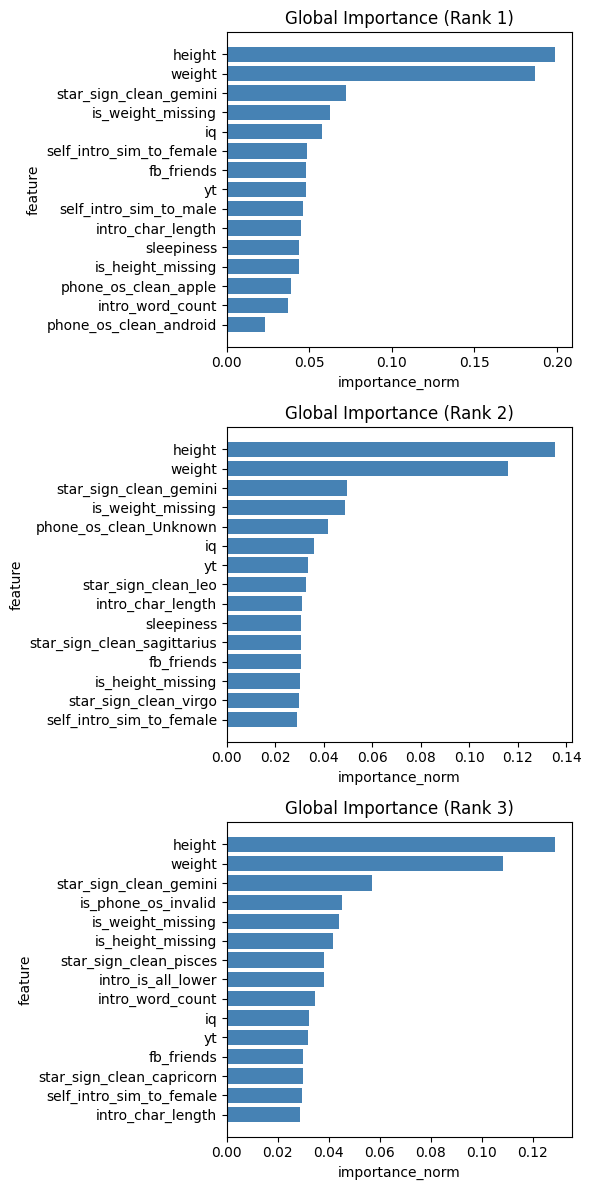

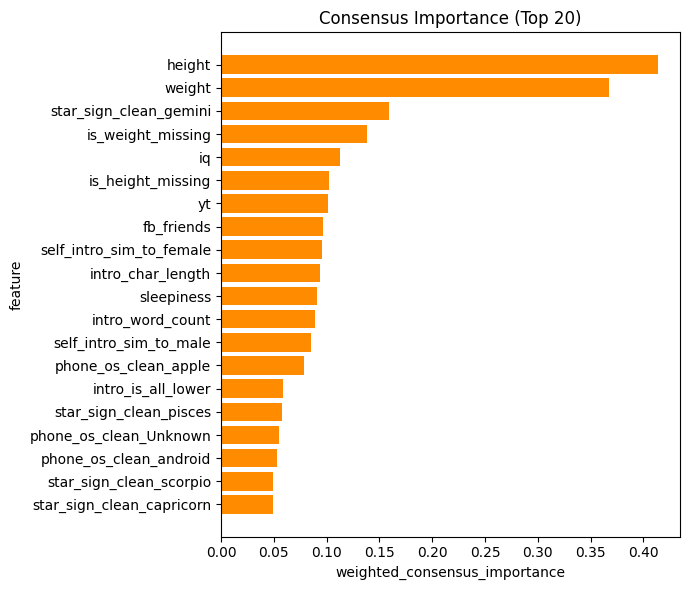

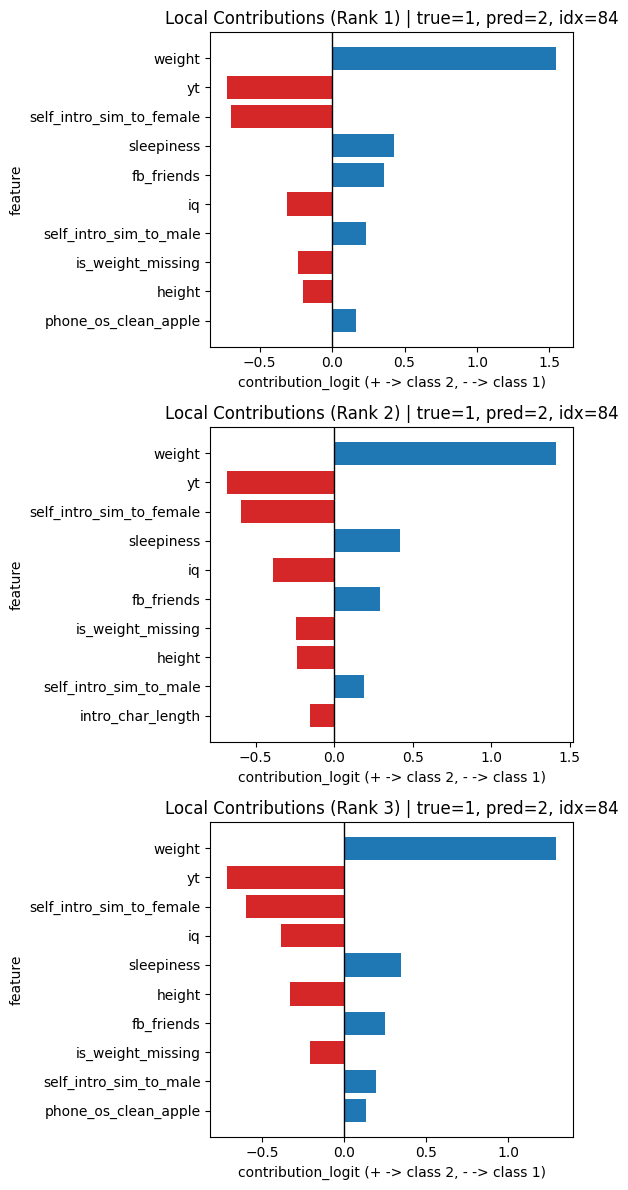

In [15]:
# Visualization helpers for explainability outputs
# Requires: all_importance_tables / consensus_df / _get_explain_models / X_valid_base / y_valid / label_offset

import matplotlib.pyplot as plt


def plot_topk_global_importance(topk=3, topn=15, figsize_per_plot=(6, 4)):
    if 'all_importance_tables' not in globals() or len(all_importance_tables) == 0:
        print('all_importance_tables not found. Please run Cell 20 first.')
        return

    topk = int(max(1, topk))
    nrows = min(topk, len(all_importance_tables))
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(figsize_per_plot[0], figsize_per_plot[1] * nrows))
    if nrows == 1:
        axes = [axes]

    for i in range(nrows):
        key = f'rank_{i + 1}'
        if key not in all_importance_tables:
            continue

        df = all_importance_tables[key].head(topn).iloc[::-1]
        ax = axes[i]
        ax.barh(df['feature'], df['importance_norm'], color='steelblue')
        ax.set_title(f'Global Importance (Rank {i + 1})')
        ax.set_xlabel('importance_norm')
        ax.set_ylabel('feature')

    plt.tight_layout()
    plt.show()


def plot_consensus_importance(topn=20, figsize=(7, 6)):
    if 'consensus_df' not in globals() or len(consensus_df) == 0:
        print('consensus_df not found. Please run Cell 20 first.')
        return

    df = consensus_df.head(topn).iloc[::-1]
    plt.figure(figsize=figsize)
    plt.barh(df['feature'], df['weighted_consensus_importance'], color='darkorange')
    plt.title(f'Consensus Importance (Top {topn})')
    plt.xlabel('weighted_consensus_importance')
    plt.ylabel('feature')
    plt.tight_layout()
    plt.show()


def plot_case_local_contributions(valid_id=None, valid_index=None, scope='cv', topk=3, topn=10, figsize_per_plot=(6, 4)):
    if valid_id is None and valid_index is None:
        raise ValueError('Please provide either valid_id or valid_index.')

    if 'X_valid_base' not in globals() or 'y_valid' not in globals() or 'label_offset' not in globals():
        raise RuntimeError('Missing required variables. Please run training/preprocessing cells first.')

    if valid_index is None:
        if 'valid_ids' in globals() and valid_ids is not None:
            valid_ids_ref = pd.Series(valid_ids).reset_index(drop=True)
        elif 'id' in X_valid.columns:
            valid_ids_ref = pd.Series(X_valid['id']).reset_index(drop=True)
        else:
            raise RuntimeError('No valid id column found. Use valid_index instead.')

        matched = np.where(valid_ids_ref.values == valid_id)[0]
        if len(matched) == 0:
            raise ValueError(f'valid_id={valid_id} not found in validation set.')
        sample_idx = int(matched[0])
    else:
        sample_idx = int(valid_index)

    models = _get_explain_models(scope=scope, topk=topk)
    if len(models) == 0:
        print(f'No artifacts available for scope={scope}.')
        return

    nrows = len(models)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(figsize_per_plot[0], figsize_per_plot[1] * nrows))
    if nrows == 1:
        axes = [axes]

    for i, art in enumerate(models, start=1):
        model = art['model']
        cols = art['selected_cols']
        x_row = X_valid_base[cols].iloc[[sample_idx]]

        pred_cv = int(model.predict(x_row)[0])
        pred_label = int(pred_cv + label_offset)
        true_label = int(y_valid.iloc[sample_idx])

        booster = model.get_booster()
        drow = xgb.DMatrix(x_row, feature_names=cols)
        contrib = booster.predict(drow, pred_contribs=True)[0]

        local_df = pd.DataFrame({
            'feature': cols,
            'contribution_logit': contrib[:-1]
        })
        local_df['abs_contribution'] = local_df['contribution_logit'].abs()
        local_df = local_df.sort_values('abs_contribution', ascending=False).head(topn).iloc[::-1]

        colors = ['#1f77b4' if v >= 0 else '#d62728' for v in local_df['contribution_logit']]
        ax = axes[i - 1]
        ax.barh(local_df['feature'], local_df['contribution_logit'], color=colors)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(
            f'Local Contributions (Rank {i}) | true={true_label}, pred={pred_label}, idx={sample_idx}'
        )
        ax.set_xlabel('contribution_logit (+ -> class 2, - -> class 1)')
        ax.set_ylabel('feature')

    plt.tight_layout()
    plt.show()


# Example visualizations (edit and rerun)
plot_topk_global_importance(topk=3, topn=15)
plot_consensus_importance(topn=20)
plot_case_local_contributions(valid_id=119, scope='cv', topk=3, topn=10)


## Kaggle Submission file

In [17]:
# Create submission files for top CV and No-CV models, with flexible export control
# ---------- Export control ----------
# export_mode:
# - 'all'   : export both CV top-k and No-CV top-k
# - 'cv'    : export only CV top-k
# - 'nocv'  : export only No-CV top-k
# - 'single': export only a single specified combination (controlled by single_target or single_spec)
export_mode = 'all'

# For mode in {'all', 'cv', 'nocv'}
export_topk = 4

# For mode == 'single': rank-based target specification
# tag: 'cv' or 'nocv', rank starts from 1
single_target = {
    'tag': 'nocv',
    'rank': 1
}

# For mode == 'single': you can also specify by strategy (higher priority than single_target)
# Keep None if not used
single_spec = None
# Example:
# single_spec = {
#     'tag': 'cv',
#     'resampling': 'xgb_cost_sensitive',
#     'feature_selection': 'top_30_rf'
# }


if 'test_ids' not in globals() or test_ids is None:
    print('Error: test_ids has not been created yet. Please run the preprocessing cell first.')
else:
    def _order_by_rank_df(rank_df, artifacts):
        artifact_map = {(a['resampling'], a['feature_selection']): a for a in artifacts}
        ordered = []
        for _, r in rank_df.iterrows():
            key = (r['resampling'], r['feature_selection'])
            if key in artifact_map:
                ordered.append(artifact_map[key])
        return ordered

    def get_artifacts_by_tag(tag):
        # Prefer ranking table order from the previous cell to keep export order consistent
        if tag == 'cv':
            if 'all_artifacts' in globals() and len(all_artifacts) > 0:
                if 'experiment_df' in globals() and len(experiment_df) > 0:
                    ordered = _order_by_rank_df(experiment_df, all_artifacts)
                    if len(ordered) > 0:
                        return ordered
                # Fallback: if ranking table is unavailable, still export by sorted score
                return sorted(
                    all_artifacts,
                    key=lambda x: x.get('valid_f1_macro', -np.inf),
                    reverse=True
                )
            if 'top3_artifacts' in globals() and len(top3_artifacts) > 0:
                return top3_artifacts
            return []

        if tag == 'nocv':
            if 'no_cv_artifacts' in globals() and len(no_cv_artifacts) > 0:
                if 'no_cv_df' in globals() and len(no_cv_df) > 0:
                    ordered = _order_by_rank_df(no_cv_df, no_cv_artifacts)
                    if len(ordered) > 0:
                        return ordered
                # Fallback: if ranking table is unavailable, still export by sorted score
                return sorted(
                    no_cv_artifacts,
                    key=lambda x: x.get('valid_f1_macro', -np.inf),
                    reverse=True
                )
            if 'top3_artifacts_nocv' in globals() and len(top3_artifacts_nocv) > 0:
                return top3_artifacts_nocv
            return []

        raise ValueError(f'Unknown tag: {tag}')

    def export_items(items, tag):
        if items is None or len(items) == 0:
            print(f'[{tag}] No available artifacts. Skipped.')
            return []

        saved_files = []
        for i, art in enumerate(items, start=1):
            preds_cv = art['model'].predict(art['X_test_sel'])
            preds = preds_cv + label_offset

            submission_i = pd.DataFrame({
                'id': test_ids,
                'gender': preds
            })

            out_path = f'submission_{tag}_{i}_{art["resampling"]}_{art["feature_selection"]}_328.csv'
            submission_i.to_csv(out_path, index=False)
            saved_files.append(out_path)
            print(f'[{tag}] Saved: {out_path}')

        return saved_files

    def pick_by_rank(artifacts, rank_1based):
        if rank_1based < 1 or rank_1based > len(artifacts):
            raise ValueError(f'Rank out of range: {rank_1based}. Valid range is 1..{len(artifacts)}')
        return [artifacts[rank_1based - 1]]

    def pick_by_spec(artifacts, resampling, feature_selection):
        picked = [
            a for a in artifacts
            if a.get('resampling') == resampling and a.get('feature_selection') == feature_selection
        ]
        if len(picked) == 0:
            raise ValueError(f'Specified combination not found: resampling={resampling}, feature_selection={feature_selection}')
        return [picked[0]]

    cv_saved, nocv_saved = [], []

    if export_mode == 'all':
        cv_artifacts = get_artifacts_by_tag('cv')
        nocv_artifacts = get_artifacts_by_tag('nocv')
        print(f"[cv] Available artifacts: {len(cv_artifacts)}, planned exports: {min(export_topk, len(cv_artifacts))}")
        print(f"[nocv] Available artifacts: {len(nocv_artifacts)}, planned exports: {min(export_topk, len(nocv_artifacts))}")

        cv_items = cv_artifacts[:export_topk]
        nocv_items = nocv_artifacts[:export_topk]
        cv_saved = export_items(cv_items, 'cv')
        nocv_saved = export_items(nocv_items, 'nocv')

    elif export_mode in ['cv', 'nocv']:
        artifacts = get_artifacts_by_tag(export_mode)
        print(f"[{export_mode}] Available artifacts: {len(artifacts)}, planned exports: {min(export_topk, len(artifacts))}")
        items = artifacts[:export_topk]
        saved = export_items(items, export_mode)
        if export_mode == 'cv':
            cv_saved = saved
        else:
            nocv_saved = saved

    elif export_mode == 'single':
        if single_spec is not None:
            tag = single_spec['tag']
            artifacts = get_artifacts_by_tag(tag)
            items = pick_by_spec(
                artifacts,
                single_spec['resampling'],
                single_spec['feature_selection']
            )
            saved = export_items(items, tag)
        else:
            tag = single_target['tag']
            artifacts = get_artifacts_by_tag(tag)
            items = pick_by_rank(artifacts, single_target['rank'])
            saved = export_items(items, tag)

        if tag == 'cv':
            cv_saved = saved
        else:
            nocv_saved = saved

    else:
        raise ValueError("export_mode must be one of 'all'/'cv'/'nocv'/'single'")

    if len(cv_saved) == 0 and len(nocv_saved) == 0:
        if 'final_model' in globals() and 'X_test_best' in globals():
            test_preds_cv = final_model.predict(X_test_best)
            test_preds = test_preds_cv + label_offset
            submission = pd.DataFrame({'id': test_ids, 'gender': test_preds})
            fallback_path = 'submission_fallback.csv'
            submission.to_csv(fallback_path, index=False)
            print(f'Fallback export succeeded: {fallback_path}')
            print(submission.head())
        else:
            print('No exportable model found (top3_artifacts / top3_artifacts_nocv / final_model).')
    else:
        if len(cv_saved) > 0:
            print('\nCV first output preview:')
            print(pd.read_csv(cv_saved[0]).head())
        if len(nocv_saved) > 0:
            print('\nNo-CV first output preview:')
            print(pd.read_csv(nocv_saved[0]).head())

[cv] Available artifacts: 40, planned exports: 4
[nocv] Available artifacts: 40, planned exports: 4
[cv] Saved: submission_cv_1_xgb_cost_sensitive_top_30_rf_328.csv
[cv] Saved: submission_cv_2_xgb_cost_sensitive_top_15_rf_328.csv
[cv] Saved: submission_cv_3_xgb_cost_sensitive_top_20_rf_328.csv
[cv] Saved: submission_cv_4_xgb_cost_sensitive_all_features_328.csv
[nocv] Saved: submission_nocv_1_xgb_cost_sensitive_top_30_rf_328.csv
[nocv] Saved: submission_nocv_2_xgb_cost_sensitive_top_15_rf_328.csv
[nocv] Saved: submission_nocv_3_xgb_cost_sensitive_top_20_rf_328.csv
[nocv] Saved: submission_nocv_4_xgb_cost_sensitive_all_features_328.csv

CV first output preview:
   id  gender
0   1       1
1   2       1
2   3       2
3   4       1
4   5       2

No-CV first output preview:
   id  gender
0   1       1
1   2       1
2   3       2
3   4       1
4   5       2
